# Mini Project. Shark Attacks

**Business hypothesis**
An insurance company can increase its profits by selling certain products in countries with the hughest number of shark attacks. 
The main focus group: travelers who enjoy a specific water sport (surf, diving, etc.)

**Dataset for research**
[Shark Attack dataset](https://www.sharkattackfile.net/incidentlog.htm)

## Step 1. Load and evaluating data

In [322]:
import pandas as pd

url = '/Users/k.yukhlina/IronHack/Week_2/Day_1/GSAF5.xls'
shark_df = pd.read_excel(url, engine="xlrd")
shark_df

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026.0,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,...,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026.0,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,...,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026.0,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,...,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th June,2026.0,Unprovoked,Galapogos Islands,Santa Fe Island,Mosquera Islet,Snorkeling,Australia Woman,F,?,...,Unknown,Andrew Currie: Facebook: AbsolutCruceros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th June,2026.0,Unprovoked,USA,Florida,Panama City,Swimming,Unknown,M,20's,...,2.4m (8ft) Bull shark,James Kingsley:Todd Smith: Kevin McMurray Trac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7098,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN
7099,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN
7100,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN
7101,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN


**Datatypes**

In [323]:
shark_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7103 entries, 0 to 7102
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7103 non-null   object 
 1   Year            7101 non-null   float64
 2   Type            7085 non-null   str    
 3   Country         7053 non-null   str    
 4   State           6616 non-null   str    
 5   Location        6536 non-null   str    
 6   Activity        6520 non-null   str    
 7   Name            6885 non-null   str    
 8   Sex             6525 non-null   str    
 9   Age             4109 non-null   object 
 10  Injury          7067 non-null   str    
 11  Fatal Y/N       6542 non-null   object 
 12  Time            3576 non-null   object 
 13  Species         3972 non-null   str    
 14  Source          7083 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   str    
 17  href            6796 non-null   str    
 18 

**Shape**

In [324]:
shark_df.shape

(7103, 23)

**Unique values**

In [325]:
shark_df.nunique()

Date              6140
Year               261
Type                14
Country            254
State              952
Location          4644
Activity          1613
Name              5813
Sex                 12
Age                252
Injury            4211
Fatal Y/N           12
Time               485
Species           1757
Source            5428
pdf               6789
href formula      6784
href              6776
Case Number       6777
Case Number.1     6775
original order    6797
Unnamed: 21          1
Unnamed: 22          2
dtype: int64

**Count the number of null values in each column**

In [326]:
shark_df.isna().sum()

Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                304
href formula       309
href               307
Case Number        305
Case Number.1      306
original order     304
Unnamed: 21       7102
Unnamed: 22       7101
dtype: int64

**Data issues:**
- We have too many categorial values for columns: 'Sex', 'Fatal Y/N', 'Type'. We need to clean the data so that are 2 categories in each column
- Unneseccery columns: 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22'. We can drop them
- We need to analyse data in 'Fatal Y/N' in case we can use them
- To cast datatypes for columns:
  - 'Year' - cast into 'int' to use in filterings
  - 'Fatal Y/N' - cast into 'str'

## Step 2. Cleaning

In [327]:
shark_df["Fatal Y/N"].value_counts()

Fatal Y/N
N          4956
Y          1494
UNKNOWN      71
 N            7
F             5
M             3
n             1
Nq            1
2017          1
Y x 2         1
N             1
y             1
Name: count, dtype: int64

**The function for cleaning data**

In [328]:
def clear_data (dataf: pd.Series) -> pd.Series:
    dataf = dataf.str.upper().str.strip()
    return dataf

In [329]:
copy_shark_df = shark_df.copy()

mapping_replacement_1 = {'Y X 2': 'Y', 'F': 'Y', 'M': 'Y', 'NQ': 'UNKNOWN'}
copy_shark_df["Fatal Y/N"] = clear_data(copy_shark_df["Fatal Y/N"])
copy_shark_df["Fatal Y/N"] = [mapping_replacement_1.get(x, x) for x in copy_shark_df["Fatal Y/N"]]

In [331]:
copy_shark_df["Fatal Y/N"].value_counts()

Fatal Y/N
N          4965
Y          1504
UNKNOWN      72
Name: count, dtype: int64

**Conclusions about data in 'Fatal Y/N' column**
- The column contains strings that can be useful for analysis
- We assume that 'F' stands for 'Fatal', 'M' stands for  'Mortal', 'NQ' stands for 'UNKNOWN'. This allows us to categorise the data into three groups. 

The 'Fatal Y/N' column contains information that could be useful for designing life insurance coverage:
1. 'Full coverage' - covers both death and injuries resulting from shark attacks. We can use the data with 'Y' values.
2. 'Injuries only' - covers injuries resulting from shark attacks (excludes fatal cases). We can use the data with 'N' and 'UNKNOWN' values.

Instead of dropping unnecessary data I decided to use data for 10 past years:

In [332]:
copy_shark_df_10 = copy_shark_df[(copy_shark_df["Year"] > 2015)]
copy_shark_df_10["Year"]= copy_shark_df_10["Year"].map(int)
copy_shark_df_10.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,...,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,...,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,...,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th June,2026,Unprovoked,Galapogos Islands,Santa Fe Island,Mosquera Islet,Snorkeling,Australia Woman,F,?,...,Unknown,Andrew Currie: Facebook: AbsolutCruceros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th June,2026,Unprovoked,USA,Florida,Panama City,Swimming,Unknown,M,20's,...,2.4m (8ft) Bull shark,James Kingsley:Todd Smith: Kevin McMurray Trac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [333]:
#Inspecting NaN 
copy_shark_df_10.isna().any()

Date              False
Year              False
Type               True
Country            True
State              True
Location           True
Activity           True
Name               True
Sex                True
Age                True
Injury             True
Fatal Y/N          True
Time               True
Species            True
Source             True
pdf                True
href formula       True
href               True
Case Number        True
Case Number.1      True
original order     True
Unnamed: 21        True
Unnamed: 22        True
dtype: bool

In [334]:
copy_shark_df_5 = copy_shark_df[(copy_shark_df["Year"] > 2021)]
copy_shark_df_5["Year"]= copy_shark_df_5["Year"].map(int)
copy_shark_df_5.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,...,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,...,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,...,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th June,2026,Unprovoked,Galapogos Islands,Santa Fe Island,Mosquera Islet,Snorkeling,Australia Woman,F,?,...,Unknown,Andrew Currie: Facebook: AbsolutCruceros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th June,2026,Unprovoked,USA,Florida,Panama City,Swimming,Unknown,M,20's,...,2.4m (8ft) Bull shark,James Kingsley:Todd Smith: Kevin McMurray Trac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [335]:
copy_shark_df_1 = copy_shark_df[(copy_shark_df["Year"] > 2025)]
copy_shark_df_1["Year"]= copy_shark_df_1["Year"].map(int)
copy_shark_df_1.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,...,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,...,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,...,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th June,2026,Unprovoked,Galapogos Islands,Santa Fe Island,Mosquera Islet,Snorkeling,Australia Woman,F,?,...,Unknown,Andrew Currie: Facebook: AbsolutCruceros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th June,2026,Unprovoked,USA,Florida,Panama City,Swimming,Unknown,M,20's,...,2.4m (8ft) Bull shark,James Kingsley:Todd Smith: Kevin McMurray Trac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [336]:
#Inspecting NaN 
copy_shark_df_1.isna().any()

Date              False
Year              False
Type              False
Country           False
State             False
Location          False
Activity          False
Name              False
Sex               False
Age               False
Injury             True
Fatal Y/N         False
Time              False
Species           False
Source            False
pdf                True
href formula       True
href               True
Case Number        True
Case Number.1      True
original order     True
Unnamed: 21        True
Unnamed: 22        True
dtype: bool

**Conclusions about NaN values**

- There are missing values in almost in evry column, but we don't need to use all this data. We can filter the dataset for the required time period and focus on the countries with the highest number of shark attacks.
- We observed that the dataset with cases for past 5 years has no missing values in 'Country' column. This may indicate that this period contains more relevant data for observations
- Dataset with cases for past 1 year has minimum missing values in all necessary columns

We can proceed with the analysis using datasets from the 1 past year and the 5 past years.

**The top-5 countries with information about sharks attack for 5 past years**

In [337]:
copy_shark_df_5 = copy_shark_df_5.drop(['Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22'], axis=1)
copy_shark_df_5["Country"] = clear_data(copy_shark_df_5["Country"])
copy_shark_df_5["Country"].value_counts().head()

Country
USA             145
AUSTRALIA        96
BAHAMAS          17
SOUTH AFRICA     10
MEXICO            9
Name: count, dtype: int64

**The top-5 countries with information about sharks attack for 1 past year**

In [338]:
copy_shark_df_1 = copy_shark_df_1.drop(['Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22'], axis=1)
copy_shark_df_1["Country"] = clear_data(copy_shark_df_1["Country"])
copy_shark_df_1["Country"].value_counts().head()

Country
AUSTRALIA        18
USA               9
BRAZIL            3
BAHAMAS           2
NEW CALEDONIA     2
Name: count, dtype: int64

### **Conclusions about Country data**

- We have a top-3 of countries with shark attack cases in 5 past years and 1 past year
    -  USA
    -  AUSTRALIA
    -  BAHAMAS

Based on the number of cases in every country, we hypothesize that our insurance strategy shouldn't include new insurance plans specially for shark attacks. Instead, we can offer optional shark attack covarege as an addition to existing travel policies for travelers to the USA, Australia and the Bahamas. 

In [340]:
copy_shark_df_5['Type'] = clear_data(copy_shark_df_5['Type'])
copy_shark_df_5['Type'].value_counts()

Type
UNPROVOKED      312
PROVOKED         31
QUESTIONABLE     15
WATERCRAFT        5
SEA DISASTER      1
?                 1
Name: count, dtype: int64

In [346]:
mapping_replacement_2 = {'?': 'QUESTIONABLE', 'SEA DISASTER': 'QUESTIONABLE', 'WATERCRAFT': 'QUESTIONABLE'}
copy_shark_df_5['Type'] = [mapping_replacement_2.get(x, x) for x in copy_shark_df_5['Type']]


In [347]:
copy_shark_df_5['Type'].value_counts()

Type
UNPROVOKED      312
PROVOKED         31
QUESTIONABLE     22
Name: count, dtype: int64

In [348]:
copy_shark_df_1['Type'] = clear_data(copy_shark_df_1['Type'])

In [349]:
copy_shark_df_1['Type'].value_counts()

Type
UNPROVOKED      36
PROVOKED         3
QUESTIONABLE     1
Name: count, dtype: int64

In [350]:
copy_shark_df_5['Type'].value_counts()

Type
UNPROVOKED      312
PROVOKED         31
QUESTIONABLE     22
Name: count, dtype: int64

**Conclusions about Type data**
 - We observed that, regardless of the activity, the majority of shark attacks were unprovoked. This evidence strongly suggests the shark attack covarege should be included as an optional add-on to travel insurance policies for travelers to the USA, Australia and the Bahamas.


## Step 3. Visualisation

In [351]:
import matplotlib.pyplot as plt
import numpy as np

**Line plot with circle markers**

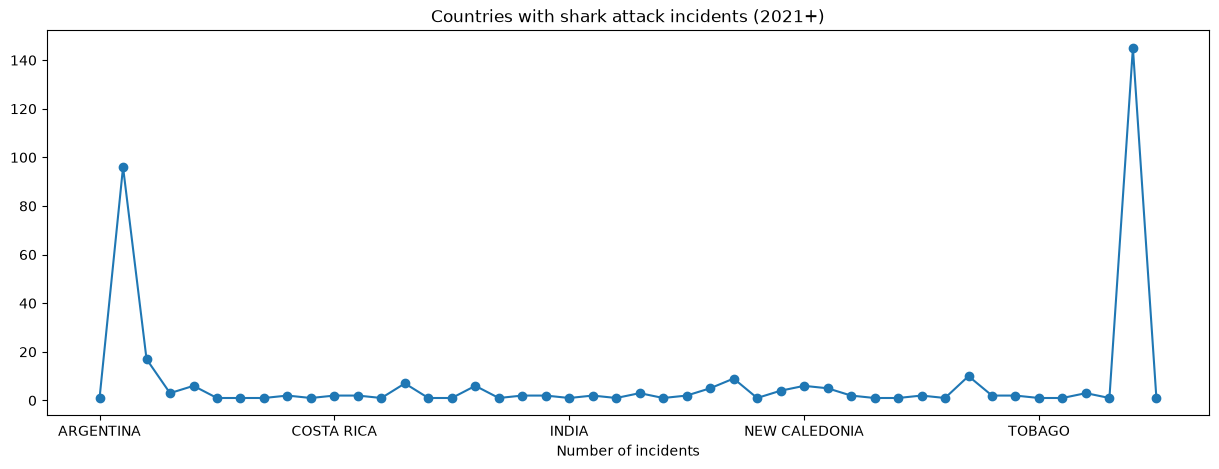

In [352]:
plt.figure(figsize=(15, 5))
f_country = copy_shark_df_5["Country"] 
countries_1 = f_country.value_counts().sort_index()
countries_1.plot(kind='line', marker='o')
plt.xlabel('Number of incidents')
plt.title('Countries with shark attack incidents (2021+)')
plt.show()

**Conclusion**

The box plot  identified two outliers corresponding to shark attacks in Australia and the USA over the past 5 years

### Pivot table with attacks in top-5 countries

In [353]:
cntr_l = ['USA', 'AUSTRALIA', 'BAHAMAS']
f_country = copy_shark_df_5[copy_shark_df_5['Country'].isin(cntr_l)]
f_country

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species
0,23rd June,2026,UNPROVOKED,BAHAMAS,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,Not stated,N,1530hrs,Unknown
1,13th June,2026,UNPROVOKED,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,Bite to back of ankle,N,1145hrs,Unknown small shark
2,13th June,2026,UNPROVOKED,AUSTRALIA,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,Bite wound to L thigh bite wounds both arms L ...,N,1115hrs,Great White Shark 4m
4,8th June,2026,UNPROVOKED,USA,Florida,Panama City,Swimming,Unknown,M,20's,Bites to both arms,N,1145hrs,2.4m (8ft) Bull shark
5,6th June,2026,UNPROVOKED,AUSTRALIA,Western Australia,Michaelmas Island King George Sound,Spearfishing,Daniel Turpin,M,35,Critical head injuries,Y,1125hrs,Great White shark 4.5 m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,24-Jan-2022,2022,UNPROVOKED,AUSTRALIA,New South Wales,Warriewood,Swimming,Jack Shackle,M,M,Foot bitten,N,NaN,Wobbegong shark
361,22-Jan-2022,2022,UNPROVOKED,AUSTRALIA,Western Australia,Whalers Beach,Snorkeling,Jack Trenow and his friend Liam,M,NaN,"Knees, ankles & feet bitten",N,NaN,Wobbegong shark
364,06-Jan-2022,2022,UNPROVOKED,USA,Florida,"Anna Maria Island, Manatee County",Wing Foil Surfing,Erika Lane,F,42,Punctures to leg,N,14h45,Blacktip or spinner shark
365,04-Jan-2022,2022,UNPROVOKED,AUSTRALIA,New South Wales,"Hyams Beach, Jervis Bay",NaN,female,F,42,Minor lacerations to lower thigh,N,06h30,NaN


In [354]:
yearly_amount_attacks = pd.pivot_table(f_country, index='Year', columns='Country', aggfunc='size', fill_value=0)
display(yearly_amount_attacks)

Country,AUSTRALIA,BAHAMAS,USA
Year,,,
2022,21,4,52
2023,21,5,46
2024,13,2,16
2025,23,4,22
2026,18,2,9


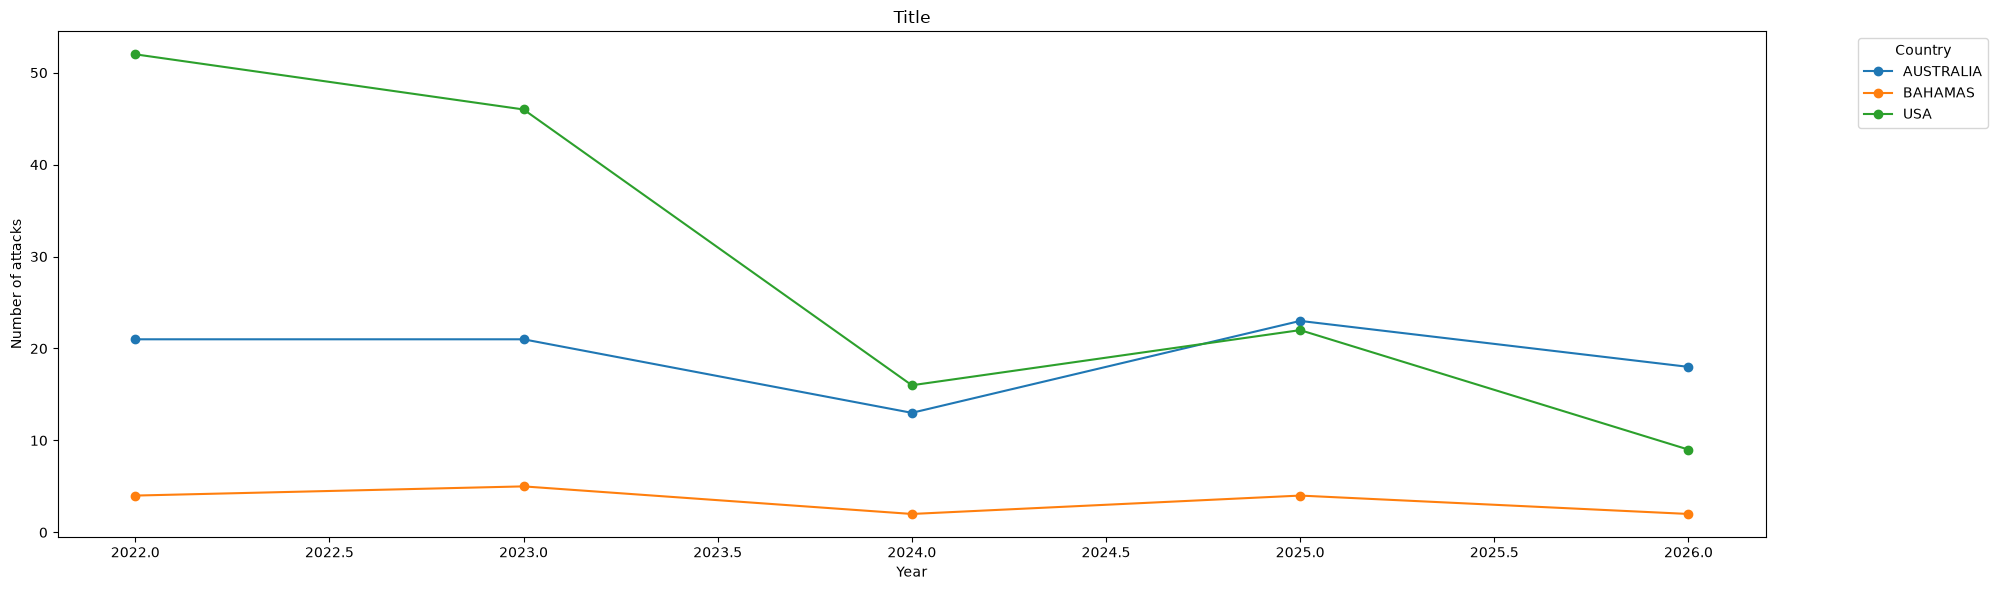

In [355]:
yearly_amount_attacks.plot(kind='line', figsize=(20,6), marker='o')
plt.xlabel('Year')
plt.ylabel('Number of attacks')
plt.title('Title')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Conclusion**

On the graph we can see a general downward trend in the number of attacks in the observed top-5 countries over the past 10 years.

**Discriptive statistics**

In [356]:
yearly_amount_attacks.describe().round(2)

Country,AUSTRALIA,BAHAMAS,USA
count,5.0,5.00,5.00
mean,19.2,3.40,29.00
std,3.9,1.34,18.95
min,13.0,2.00,9.00
25%,18.0,2.00,16.00
50%,21.0,4.00,22.00
75%,21.0,4.00,46.00
max,23.0,5.00,52.00


Discriptive statistics show that: 
- the USA recorded the highest avarage number of shark attacks
- Australia also reports a relatively high number of attacks with lower year-to-year variability than the USA
- the Bahamas have the lowest number of attacks and the most stable trend over the analyzed period

### The result
The analysis confirms the that shark attacks represent an insurance risk for travelers. However, the annual data over the past five years indicate a downward trend in the number of shark attacks. This suggests that initial hypothesis should be revised.

Instead of introducing a new travel insurance product, it would better to enhance existing travel insurance policies with optional coverage for shark attacks.

These additional coverage optionwould provide the greatest value for travelers visiting the USA, Australia and the Bahamas.